<a href="https://colab.research.google.com/github/AdwaaNasser/DataMiningProject/blob/main/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns


# Data Mining Technique

In this project, two primary data mining techniques are applied to the preprocessed dataset: classification and clustering. Each method serves a different analytical purpose and contributes to discovering meaningful patterns within the data.



# Classification : Decision Tree Classifier

For the classification task, we employ the Decision Tree Classifier from the scikit-learn library. Decision Trees are selected because they:

-Are easy to interpret and visualize

-Can handle both numerical and categorical features

-Identify the most important attributes influencing predictions

-Provide clear, rule-based decision paths that enhance understanding of the dataset

**Why Decision Trees?**

They allow us to analyze how different attributes split the data into distinct classes, and they offer transparency in how predictions are made, which is essential for the interpretation step.

**How the model is applied**
we use:

from sklearn.tree import DecisionTreeClassifier

**Two attribute selection criteria are used:**

Gini index (default):

DecisionTreeClassifier(criterion="gini")


Information Gain (Entropy):

DecisionTreeClassifier(criterion="entropy")

**The classifier is trained and evaluated using three different train/test partitions:**

90% training – 10% testing

80% training – 20% testing

70% training – 30% testing

**Model performance is assessed using:**

Accuracy score

Confusion matrix

Visualization of the decision tree

**Packages used:**

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.tree import plot_tree


# Evaluation and Comparison
**Classification :**

In [7]:
data = pd.read_csv("Preprocessed_dataset.csv")

target_column = "Air Quality"

X = data.drop(columns=[target_column])
y = data[target_column]

# encoding categorical features:
X = pd.get_dummies(X)


In [10]:
def run_decision_tree_experiments(X, y, criteria, splits, random_state=42):
    results = []

    for crit in criteria:
        for train_size in splits:
            test_size = 1 - train_size

            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                test_size=test_size,
                stratify=y,
                random_state=random_state
            )

            clf = DecisionTreeClassifier(criterion=crit, random_state=random_state)
            clf.fit(X_train, y_train)

            y_pred = clf.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            cm = confusion_matrix(y_test, y_pred)

            results.append({
                "criterion": crit,
                "train_size": train_size,
                "test_size": test_size,
                "accuracy": acc,
                "confusion_matrix": cm,
                "model": clf,
                "y_test": y_test,
                "y_pred": y_pred
            })

    return results

criteria = ["gini", "entropy"]  # Gini index and Information Gain
splits = [0.9, 0.8, 0.7]        # 90/10, 80/20, 70/30

results = run_decision_tree_experiments(X, y, criteria, splits)

In [11]:
# Build summary tables for each criterion

rows_gini = []
rows_entropy = []

for res in results:
    row = {
        "Train %": int(res["train_size"] * 100),
        "Test %": int(res["test_size"] * 100),
        "Accuracy": round(res["accuracy"], 4)
    }
    if res["criterion"] == "gini":
        rows_gini.append(row)
    else:
        rows_entropy.append(row)

gini_df = pd.DataFrame(rows_gini).sort_values(by="Train %", ascending=False)
entropy_df = pd.DataFrame(rows_entropy).sort_values(by="Train %", ascending=False)

print("=== Decision Tree with Gini Index ===")
display(gini_df)

print("=== Decision Tree with Information Gain (Entropy) ===")
display(entropy_df)


=== Decision Tree with Gini Index ===


,Train %,Test %,Accuracy
0,90,9,0.8540
1,80,19,0.8380
2,70,30,0.8514


=== Decision Tree with Information Gain (Entropy) ===


,Train %,Test %,Accuracy
0,90,9,0.8540
1,80,19,0.8390
2,70,30,0.8528


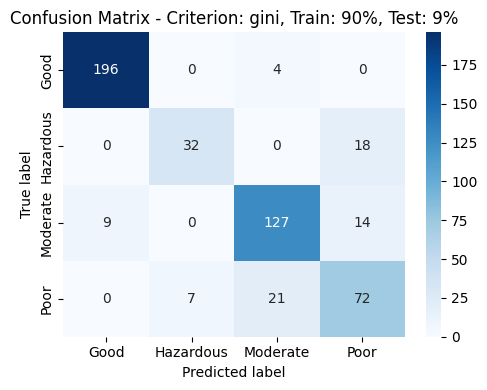

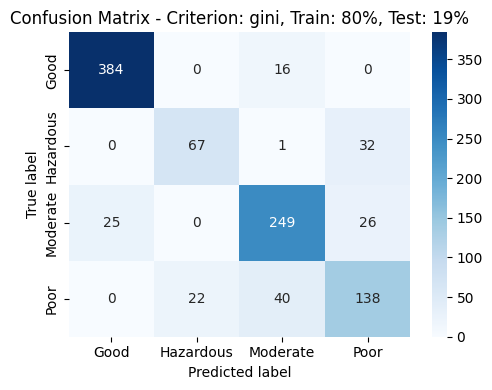

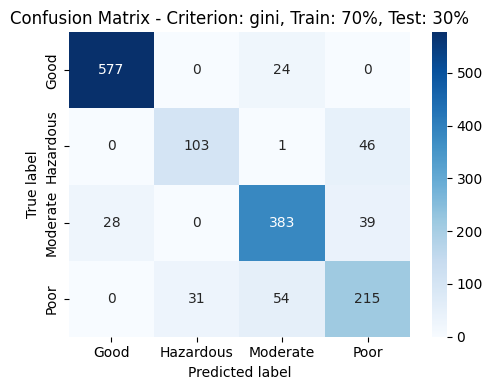

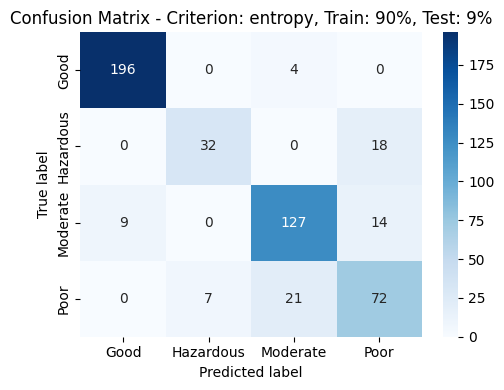

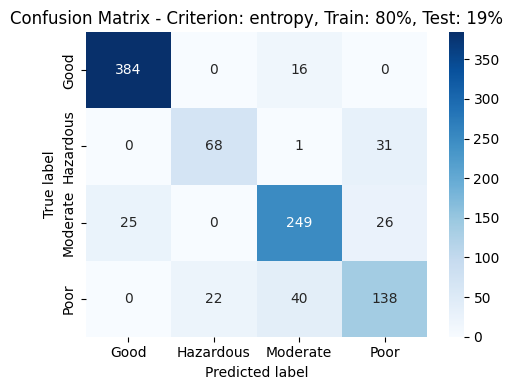

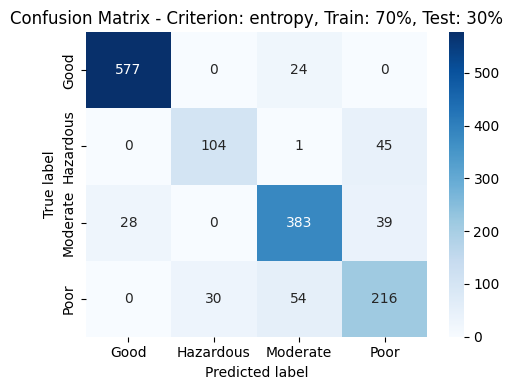

In [12]:
# Plot confusion matrices for each criterion and split

labels = sorted(y.unique())

for res in results:
    crit = res["criterion"]
    train_p = int(res["train_size"] * 100)
    test_p = int(res["test_size"] * 100)
    cm = res["confusion_matrix"]

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix - Criterion: {crit}, Train: {train_p}%, Test: {test_p}%")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


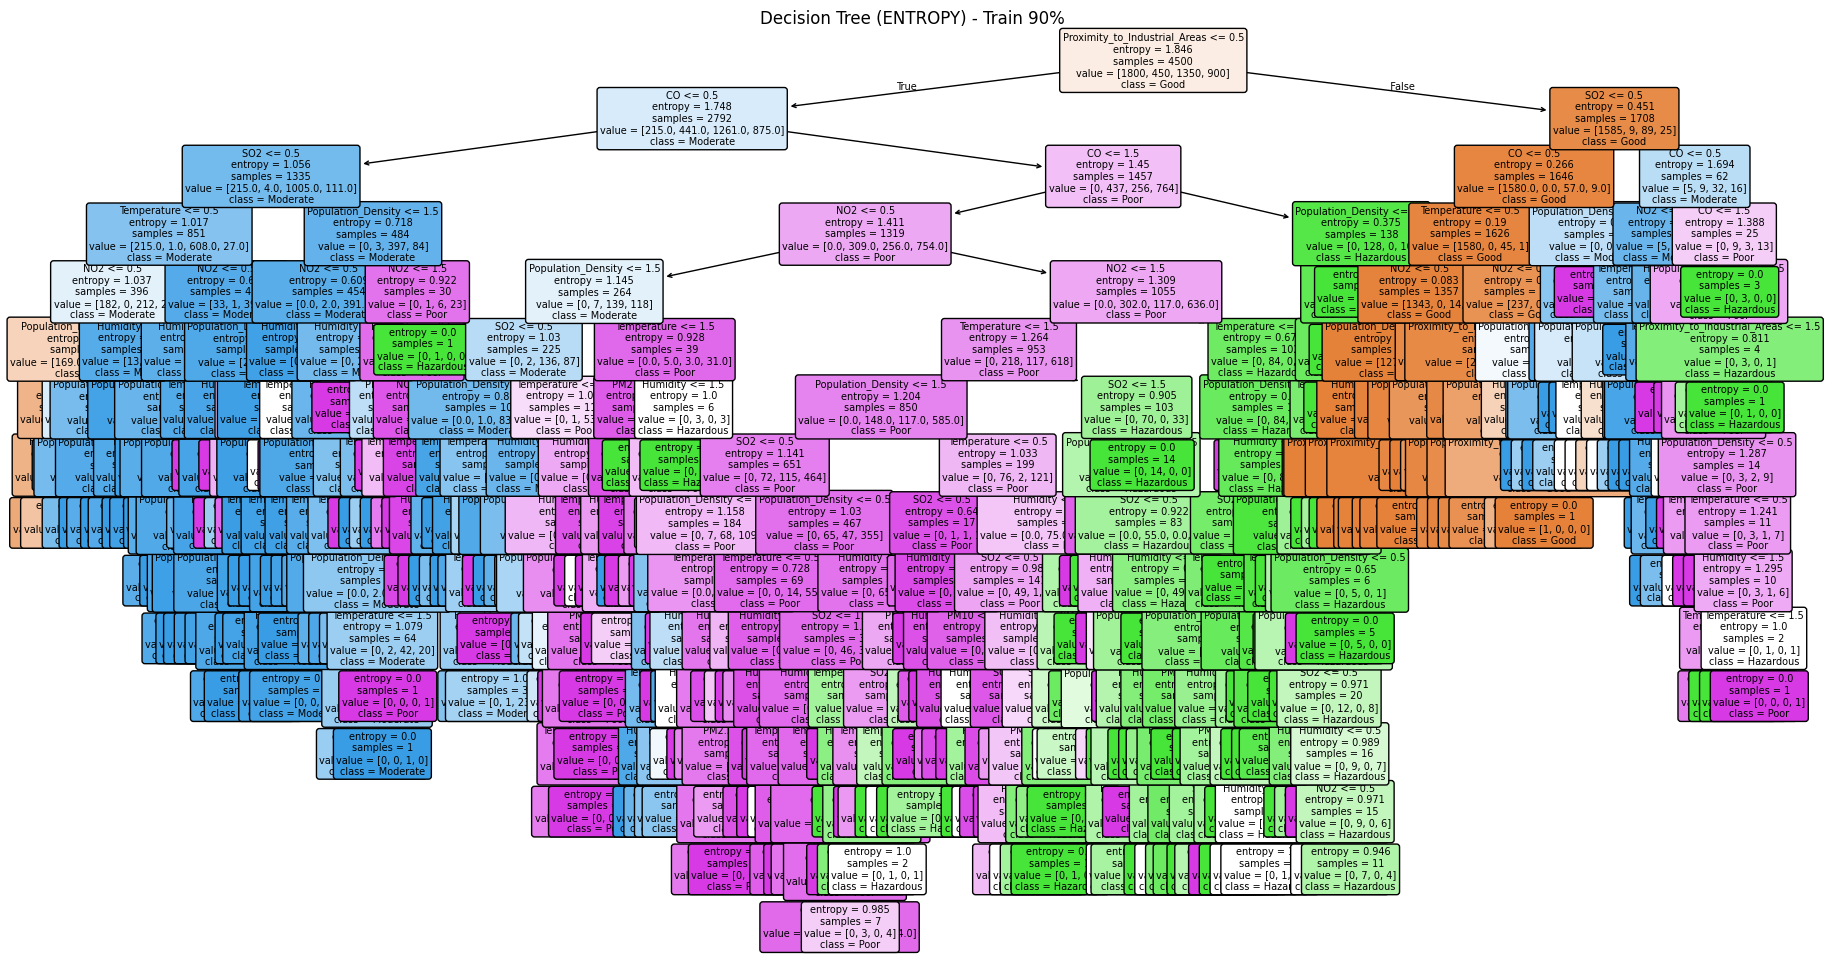

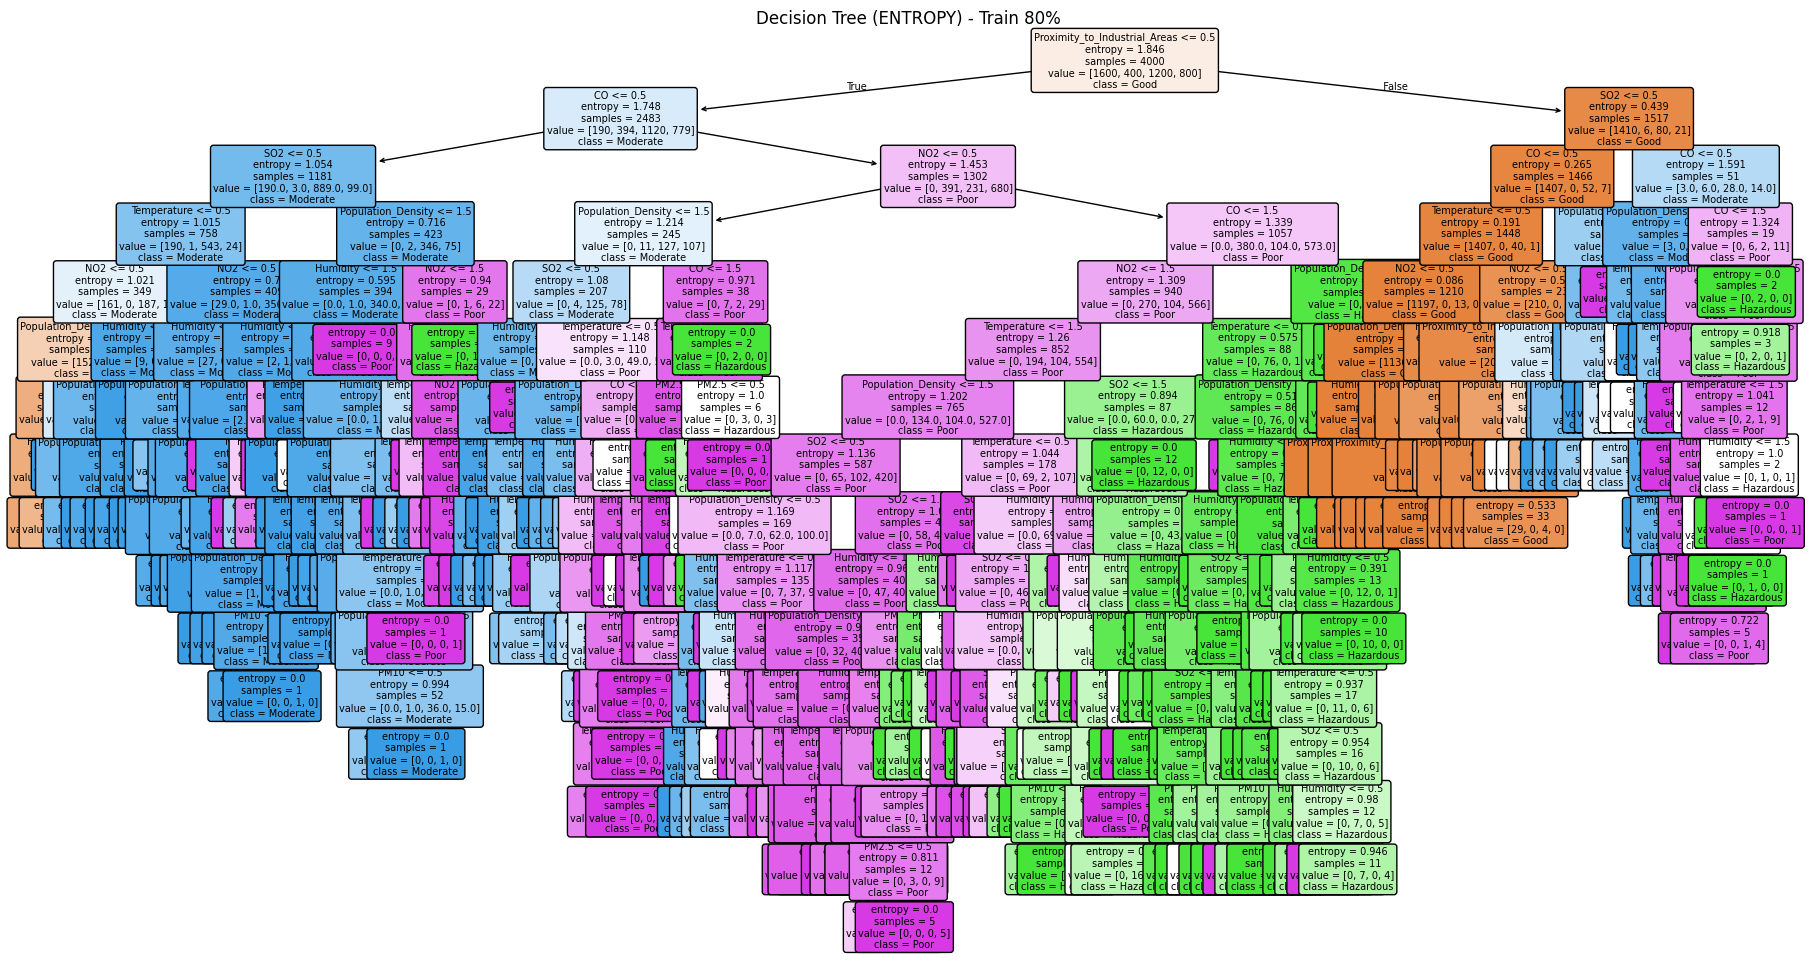

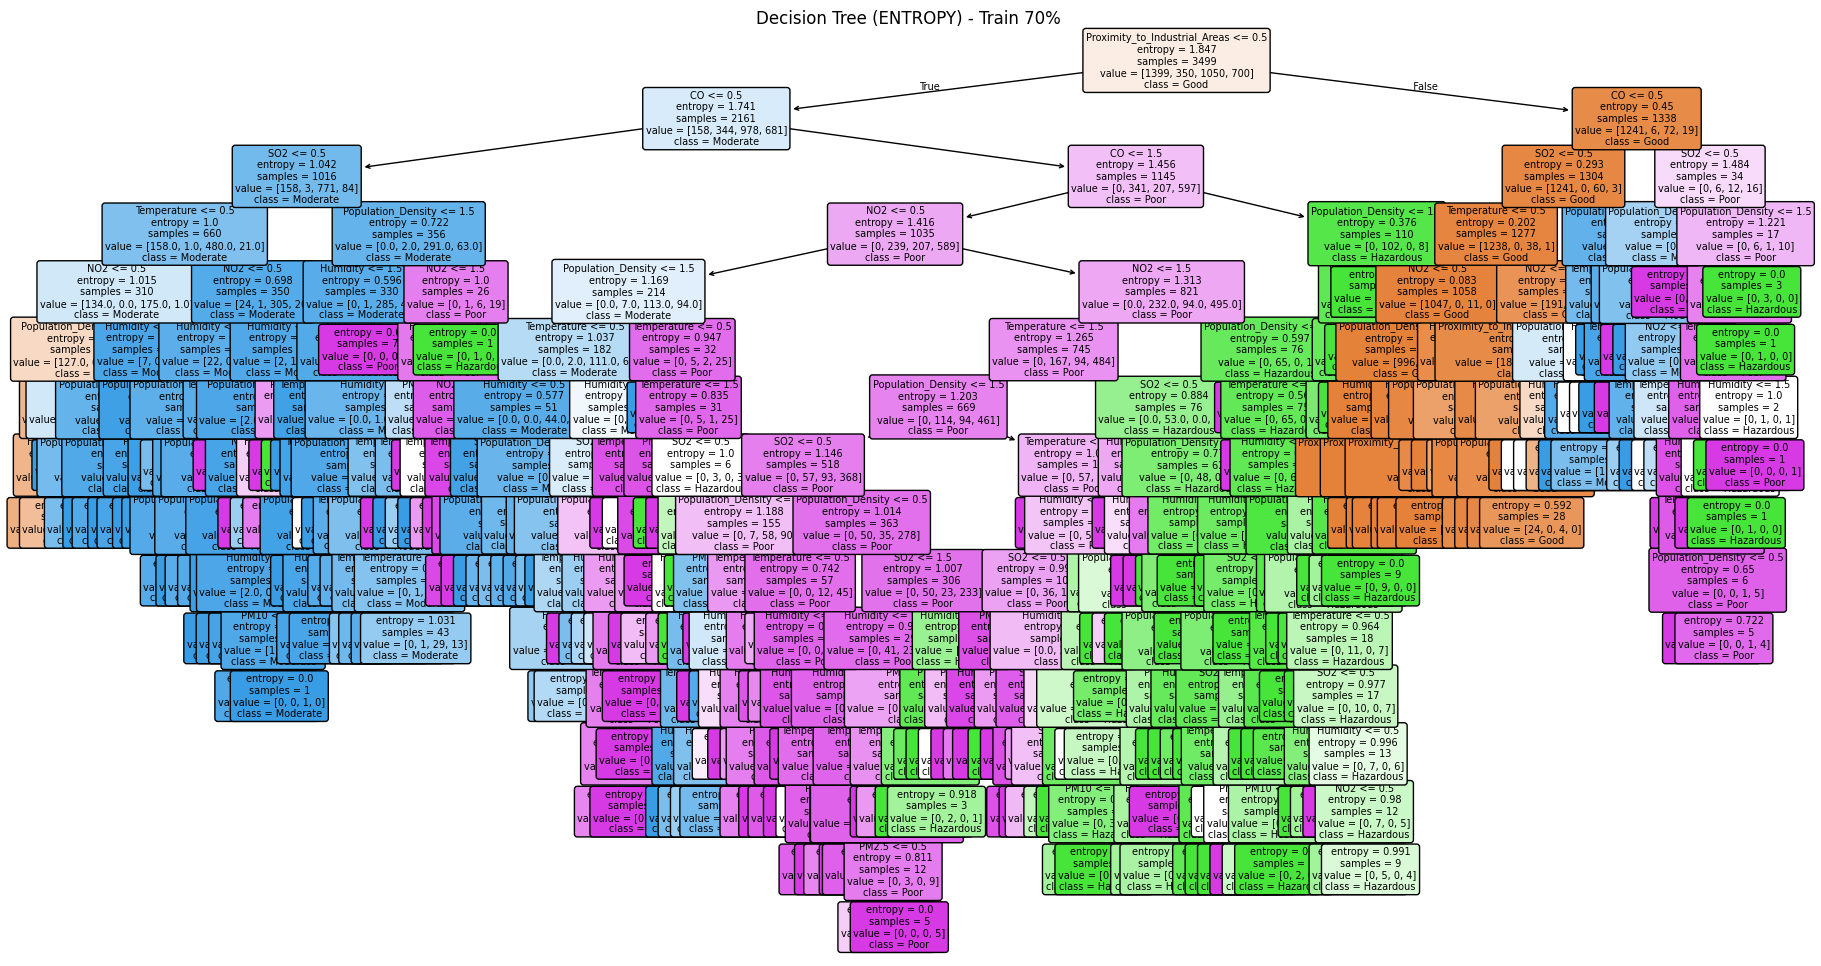

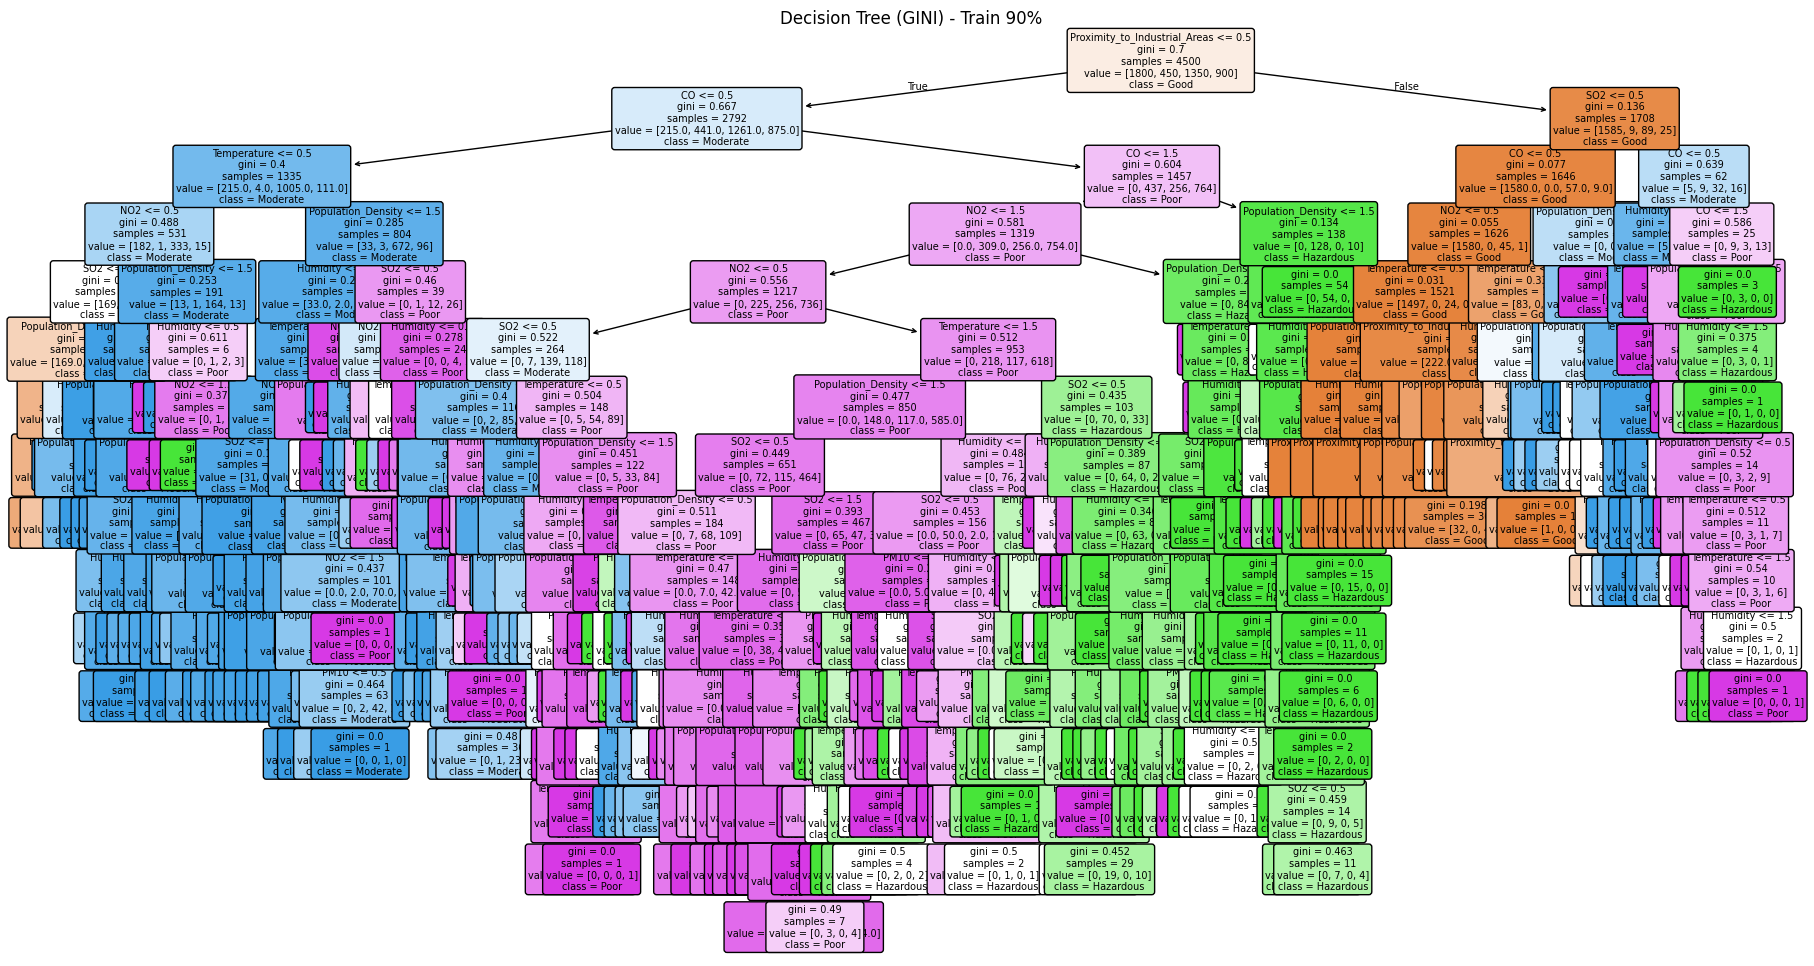

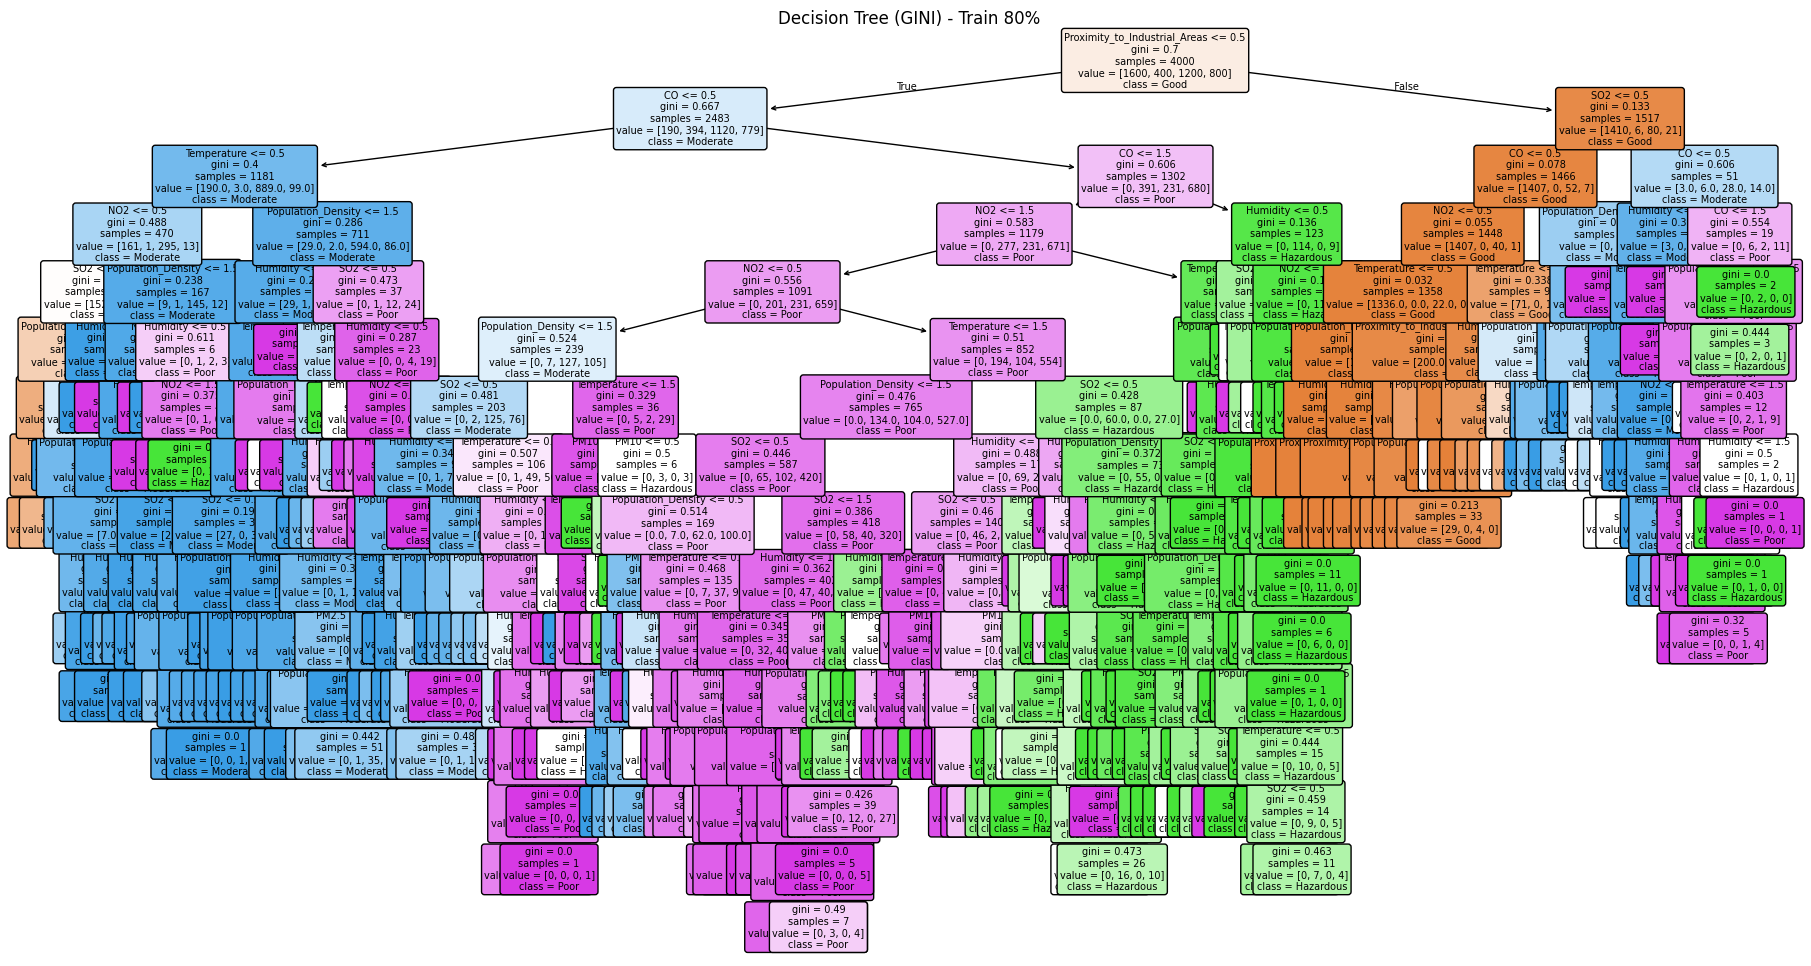

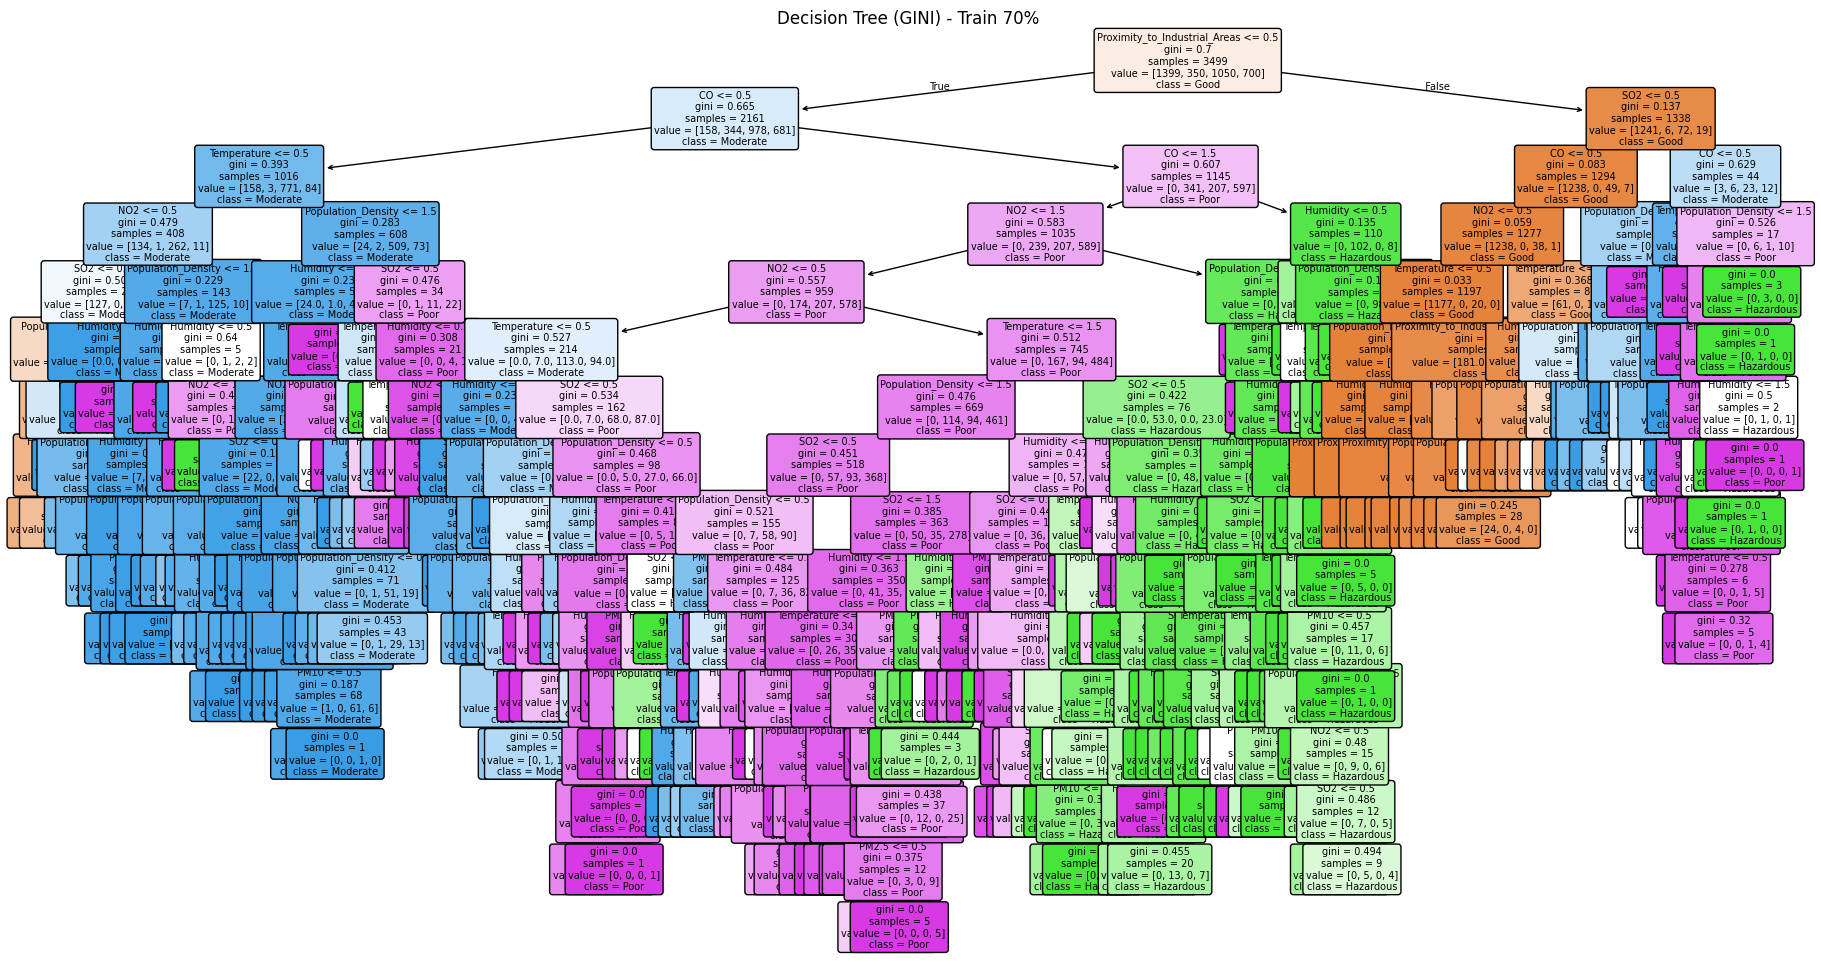

In [17]:

# Function to draw decision tree by criterion and train size
def plot_dt(criterion, train_size):
    # Find matching result
    selected = None
    for res in results:
        if res["criterion"] == criterion and round(res["train_size"], 2) == round(train_size, 2):
            selected = res
            break

    if selected is None:
        print(f"Model not found: {criterion}, train_size={train_size}")
        return

    clf = selected["model"]

    # Plot tree
    plt.figure(figsize=(22, 12))
    plot_tree(
        clf,
        feature_names=X.columns,
        class_names=[str(c) for c in sorted(y.unique())],
        filled=True,
        rounded=True,
        fontsize=7
    )
    train_percent = int(train_size * 100)
    plt.title(f"Decision Tree ({criterion.upper()}) - Train {train_percent}%")
    plt.show()


# ===========================
# 🎯 Draw 3 ENTROPY Trees
# ===========================
plot_dt("entropy", 0.9)
plot_dt("entropy", 0.8)
plot_dt("entropy", 0.7)

# ===========================
# 🎯 Draw 3 GINI Trees
# ===========================
plot_dt("gini", 0.9)
plot_dt("gini", 0.8)
plot_dt("gini", 0.7)
